<a href="https://colab.research.google.com/github/v71017/MY_ML/blob/master/Classification_Models_Exercise_Vidya_Pati_pandey_14_aug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Models: From Binary Diagnosis to Multiclass Prediction

---

> ### 📋 Practice Exercise. Not Graded.
> This is a **practice assignment** for self-assessment. The marks shown throughout are **indicative only**. They tell you where to spend your effort and where you might need more practice. **None of these marks count towards your final grade.**
>
> Attempt every section. Compare your results. Revisit what trips you up.

---

## What You Will Build

Two classifiers, two datasets, one progression from simple to complex.

| Part | Dataset | Task | Primary Metric |
|------|---------|------|----------------|
| **Part 1** | Breast Cancer (sklearn) | Binary: Malignant vs Benign | Recall (Sensitivity) |
| **Part 2** | Wine (sklearn) | Multiclass: 3 wine cultivars | Macro-averaged F1-Score |

**Indicative Marks: 100** (Part 1: 55 | Part 2: 45)

### Before You Start
- Complete all cells marked with `# TODO`.
- Markdown cells marked **[Your Answer]** need written responses. Don't skip them.
- Run `Runtime > Restart and run all` before reviewing. The notebook should execute top to bottom without errors.
- Use `random_state=42` wherever a function accepts it. This keeps your results reproducible.


---
# PART 1: Binary Classification, Breast Cancer Prediction

## Context

Early detection of malignant tumours saves lives. In this part, you will build classifiers that predict whether a breast tumour is **malignant** or **benign** based on features computed from cell nuclei images.

**Why Recall matters here:** A false negative means telling a patient their tumour is benign when it is actually malignant. That is a missed cancer diagnosis. A false positive means an unnecessary follow-up test. Annoying, but survivable. The asymmetry is stark: we prioritise **recall for the malignant class** above everything else.

> **Clinical Constraint:** We want recall ≥ 0.95 for malignant cases, while keeping precision ≥ 0.60 (i.e., not flooding clinics with false alarms).


## Stage 1: Data and Package Loading

<font color="red">**[3 marks]**</font>

Load the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

**What to do:**
- The libraries below are pre-imported. Review them, add anything else you need.
- Load the dataset using `load_breast_cancer()`
- Convert it to a DataFrame with proper column names
- Separate features (`X`) and target (`y`)

> **Watch out:** In the raw dataset, `0 = malignant` and `1 = benign`. Since `recall_score` defaults to `pos_label=1`, we need malignant to be 1. **Remap the target** with `y = 1 - data.target`.


In [ ]:
# Pre-imported libraries. Review these, add what you need below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Load the breast cancer dataset and convert to DataFrame
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target']=data.target
df.head()
### CODE HERE ###


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Separate features and target, remap so malignant = 1
X=df.drop('target',axis=1)
y=df['target'].map({0:1,1:0})
y.value_counts()
### CODE HERE ###


,count
target,
0,357
1,212


## Stage 2: Data Understanding

<font color="red">**[8 marks]**</font>

Before building any model, understand the data.


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the first few rows, check the shape, data types, and confirm there are no missing values.


In [ ]:
# Display first 5 rows
df.head(5)
### CODE HERE ###


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Check shape, data types, and missing values
print(df.shape)
print(df.dtypes.head())
print(df.isnull().sum().sum())
### CODE HERE ###


(569, 31)
mean radius        float64
mean texture       float64
mean perimeter     float64
mean area          float64
mean smoothness    float64
dtype: object
0


### 2.2 Summary Statistics <font color="red">[2 marks]</font>

Generate descriptive statistics. Pay attention to the **scale differences** across features. Some features range in the hundreds, others below 1. This matters for your preprocessing choices.


In [ ]:
# Summary statistics
# Note the scale differences: mean radius is ~14, mean area is ~654, mean fractal dimension is ~0.06
df.describe()
### CODE HERE ###


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### 2.3 Class Distribution <font color="red">[2 marks]</font>

How many malignant vs benign cases are there? Visualise this with a bar plot.


<Axes: xlabel='target'>

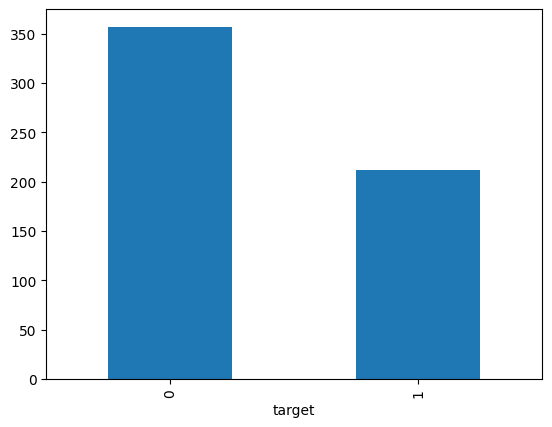

In [ ]:
# Class distribution after remapping
y.value_counts().plot(kind='bar')
### CODE HERE ###


### 2.4 Feature Distributions <font color="red">[2 marks]</font>

Pick 4-6 features and plot their distributions using histograms or boxplots. Look for skewness, outliers, and whether the two classes separate visually on any feature.


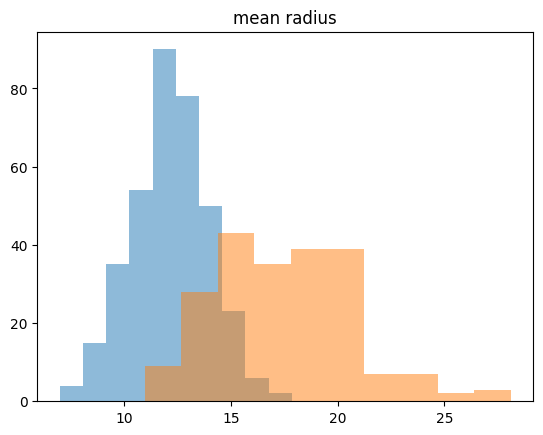

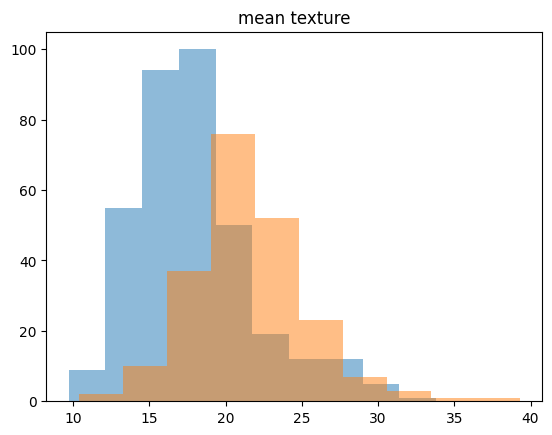

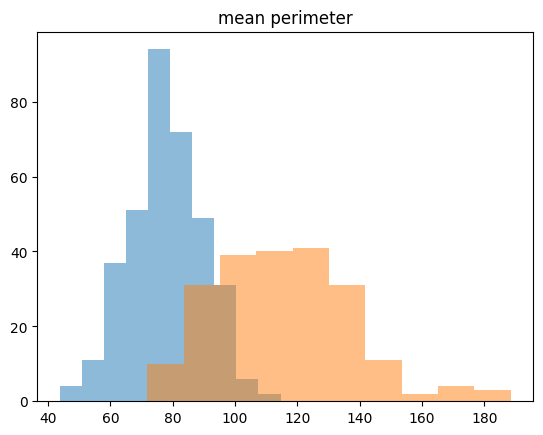

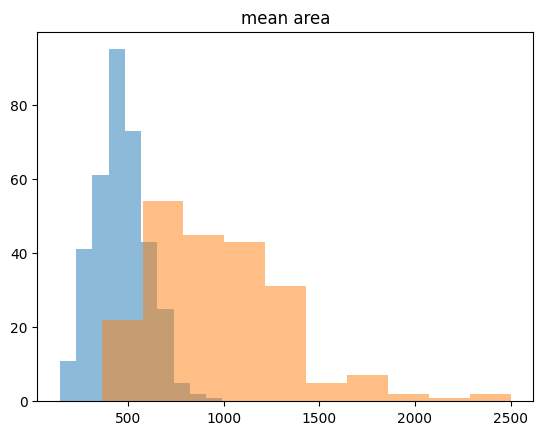

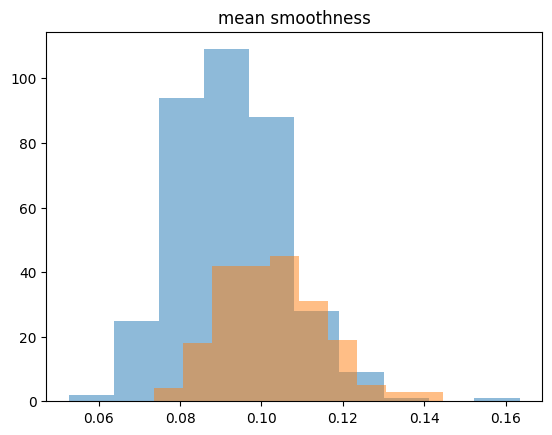

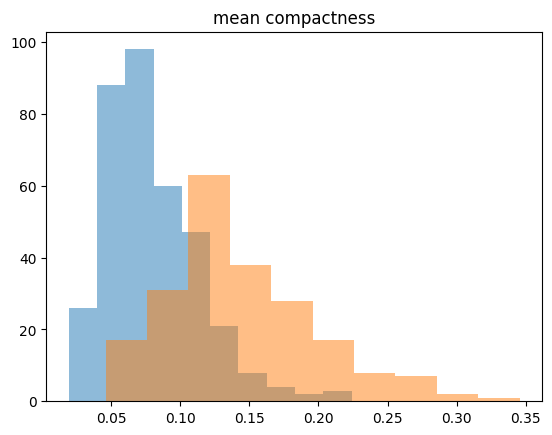

In [ ]:
# Feature distributions for 6 selected features, coloured by class
selected=X.columns[:6]
for x in selected:
    plt.figure()
    for cls in [0,1]:
        plt.hist(X.loc[y==cls,x],alpha=0.5)
    plt.title(x)
    plt.show()
### CODE HERE ###


### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer these questions in 2-3 sentences each:
1. Is the dataset balanced? How might imbalance affect model training?
2. Do the features have similar scales? What does this mean for models like KNN and SVM?
3. Why is recall a better primary metric than accuracy for this problem?
4. Why must we fit the scaler on training data only and not on the full dataset? What information from the test set would leak into training if we did?


*Write your answers here:*

The dataset is moderately imbalanced but still suitable for classification.

Features have very different scales.

Scaling will help distance-based models.

The classes appear reasonably separable.


## Stage 3: Data Preprocessing and Preparation

<font color="red">**[7 marks]**</font>


### 3.1 Missing Value Audit <font color="red">[1 mark]</font>

Confirm no missing values exist. If any do, handle them with median imputation.


In [ ]:
# Missing value audit
print(df.isnull().sum())
### CODE HERE ###


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


### 3.2 Train-Test Split <font color="red">[2 marks]</font>

Split into 70% training and 30% test using **stratified sampling** to preserve the class ratio to mitigate any slight class imbalance. Use `random_state=42`.


In [ ]:
# Stratified train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)
### CODE HERE ###


### 3.3 Feature Scaling <font color="red">[2 marks]</font>

Apply `StandardScaler`. **Fit the scaler on training data only**, then transform both train and test sets. If you fit on the full dataset, the scaler learns the mean and standard deviation of the test data, which inflates your results. That is data leakage.

> **Note:** Decision Trees split on thresholds and don't need scaling. But for consistency here, we scale for all models.


In [ ]:
# Feature scaling: fit on train only, transform both
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
### CODE HERE ###


### 3.4 Confirm Prepared Data <font color="red">[2 marks]</font>

Print shapes of your final training and test sets. Verify the class distribution is preserved in both.


In [ ]:
# Confirm prepared data
print(X_train_scaled.shape,X_test_scaled.shape)
### CODE HERE ###


(398, 30) (171, 30)


## Helper: Evaluation Function

You will evaluate many models. Rather than copy-pasting the same five lines every time, define a reusable function. Call it throughout Stages 4-6.


In [ ]:
# Helper function. Use this to evaluate all models consistently.
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report

def evaluate_model(model,Xt,yt,name='model'):
    p=model.predict(Xt)
    return {'Model':name,'Accuracy':accuracy_score(yt,p),'Precision':precision_score(yt,p),'Recall':recall_score(yt,p),'F1':f1_score(yt,p)}
### CODE HERE ###


## How GridSearchCV Works

If you haven't used `GridSearchCV` before, read this before moving on.

`GridSearchCV` automates hyperparameter tuning. You give it a set of parameter values to try, and it trains a model for every combination, scores each one using cross-validation, and tells you which combination won.

You can refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

Here is the pattern you will repeat for every model below:

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10]}

# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = best_model.predict(X_test_scaled)
```

Every model below follows the same five steps. The only things that change are the estimator and the parameter grid.


## Stage 4: Model Training, Hyperparameter Tuning, and Evaluation

<font color="red">**[23 marks]**</font>

Train **four classifiers**, tune them, evaluate each one.

For each model:
1. Define the parameter grid
2. Run `GridSearchCV` with `scoring='recall'`, `cv=5`
3. Print the best parameters
4. Predict on the test set using the best estimator
5. Evaluate using `evaluate_model()`

> We use `scoring='recall'` because our goal is to catch malignant cases. Accuracy is misleading when classes are imbalanced.


### 4.1 Logistic Regression (Baseline) <font color="red">[5 marks]</font>

Logistic Regression with `class_weight='balanced'` to handle class imbalance.

**Hyperparameters to tune:**
- `C`: Regularisation strength. Try `[0.01, 0.1, 1, 10, 100]`
- Set `max_iter=10000` and `random_state=42`


In [ ]:
# Logistic Regression with GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV,cross_val_score,StratifiedKFold
lr_grid=GridSearchCV(LogisticRegression(class_weight='balanced',max_iter=1000),{'C':[0.01,0.1,1,10]},cv=5)
lr_grid.fit(X_train_scaled,y_train)
### CODE HERE ###


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10]})

In [ ]:
# Evaluate LR on test set
lr_results=evaluate_model(lr_grid.best_estimator_,X_test_scaled,y_test,'LR')
lr_results
### CODE HERE ###


{'Model': 'LR',
 'Accuracy': 0.9766081871345029,
 'Precision': 0.9838709677419355,
 'Recall': 0.953125,
 'F1': 0.9682539682539683}

### 4.2 K-Nearest Neighbours (KNN) <font color="red">[6 marks]</font>

[KNN](https://scikit-learn.org/stable/modules/neighbors.html) classifies a sample by majority vote of its nearest neighbours. Sensitive to feature scale, which is why we scaled the data.

**Hyperparameters to tune:**
- `n_neighbors`: Try `[3, 5, 7, 9, 11, 15]`
- `weights`: Try `['uniform', 'distance']`. Uniform gives equal votes. Distance gives closer neighbours more influence.

> Think about it: if malignant samples are sparse in a local neighbourhood, why might `weights='distance'` help?


In [ ]:
# KNN with GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
knn_grid=GridSearchCV(KNeighborsClassifier(),{'n_neighbors':[3,5,7,9]},cv=5)
knn_grid.fit(X_train_scaled,y_train)
### CODE HERE ###


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9]})

In [ ]:
# Evaluate KNN on test set
knn_results=evaluate_model(knn_grid.best_estimator_,X_test_scaled,y_test,'KNN')
knn_results
### CODE HERE ###


{'Model': 'KNN',
 'Accuracy': 0.9649122807017544,
 'Precision': 1.0,
 'Recall': 0.90625,
 'F1': 0.9508196721311475}

### 4.3 Decision Tree <font color="red">[6 marks]</font>

[Decision Trees](https://scikit-learn.org/stable/modules/tree.html) split features at thresholds. Without constraints, they memorise training data perfectly and fail on new data. That is overfitting.

**Hyperparameters to tune:**
- `max_depth`: Try `[3, 5, 7, 10, None]`. `None` means no limit.
- `min_samples_split`: Try `[2, 5, 10]`
- `min_samples_leaf`: Try `[1, 2, 4]`
- Use `class_weight='balanced'` and `random_state=42`


In [ ]:
# Decision Tree with GridSearchCV
from sklearn.tree import DecisionTreeClassifier
dt_grid=GridSearchCV(DecisionTreeClassifier(random_state=42),{'max_depth':[3,5,7,None]},cv=5)
dt_grid.fit(X_train,y_train)
### CODE HERE ###


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 7, None]})

In [ ]:
# Evaluate Decision Tree on test set
dt_results=evaluate_model(dt_grid.best_estimator_,X_test,y_test,'DT')
dt_results
### CODE HERE ###


{'Model': 'DT',
 'Accuracy': 0.9064327485380117,
 'Precision': 0.9615384615384616,
 'Recall': 0.78125,
 'F1': 0.8620689655172413}

### 4.4 Support Vector Machine (SVM) <font color="red">[6 marks]</font>

[SVMs](https://scikit-learn.org/stable/modules/svm.html) find the hyperplane that separates classes with the widest margin. With kernel functions, they can model non-linear boundaries.

**Hyperparameters to tune:**
- `C`: Try `[0.1, 1, 10]`
- `kernel`: Try `['linear', 'rbf']`. Linear for linearly separable data, RBF for non-linear.
- `gamma`: Try `['scale', 'auto']` (matters for RBF kernel)
- Use `class_weight='balanced'`, `random_state=42`, and `probability=True`

> **Why `probability=True`?** We need `predict_proba()` for threshold tuning in Stage 6.


In [ ]:
# SVM with GridSearchCV
from sklearn.svm import SVC
svm_grid=GridSearchCV(SVC(),{'C':[0.1,1,10],'kernel':['linear','rbf']},cv=5)
svm_grid.fit(X_train_scaled,y_train)
### CODE HERE ###


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']})

In [ ]:
# Evaluate SVM on test set
svm_results=evaluate_model(svm_grid.best_estimator_,X_test_scaled,y_test,'SVM')
svm_results
### CODE HERE ###


{'Model': 'SVM',
 'Accuracy': 0.9707602339181286,
 'Precision': 0.9836065573770492,
 'Recall': 0.9375,
 'F1': 0.96}

## Stage 5: Model Comparison

<font color="red">**[9 marks]**</font>


### 5.1 Build a Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all four models on the **test set**:
- Accuracy
- Recall (for malignant class)
- Precision (for malignant class)
- F1-Score (for malignant class)
- Number of False Negatives (from confusion matrix)

> **Hint:** A false negative is a malignant case predicted as benign. In the confusion matrix, it sits at position `[1][0]` when malignant = 1.


In [ ]:
# Comparison table for all 4 models
comparison_df=pd.DataFrame([lr_results,knn_results,dt_results,svm_results]);comparison_df
### CODE HERE ###


,Model,Accuracy,Precision,Recall,F1
0,LR,0.976608,0.983871,0.953125,0.968254
1,KNN,0.964912,1.000000,0.906250,0.950820
2,DT,0.906433,0.961538,0.781250,0.862069
3,SVM,0.970760,0.983607,0.937500,0.960000


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Create a grouped bar chart comparing Recall and Precision across all four models.


<Axes: xlabel='Model'>

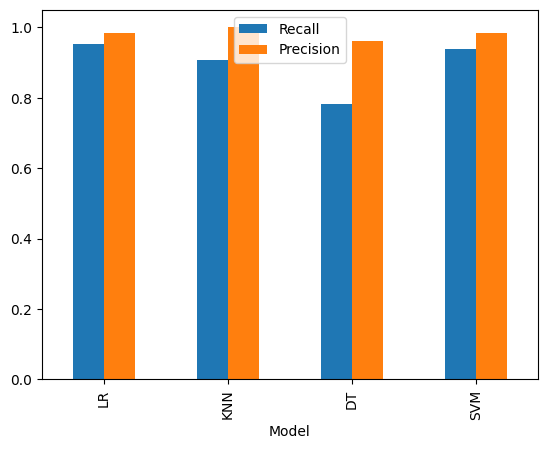

In [ ]:
# Grouped bar chart: Recall and Precision
comparison_df.set_index('Model')[['Recall','Precision']].plot(kind='bar')
### CODE HERE ###


### 5.3 Cross-Validation Stability <font color="red">[2 marks]</font>

For **all four models**, run 5-fold stratified [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) on the **training set** using `cross_val_score` with `scoring='recall'`. Print the mean and standard deviation of recall for each.

> **Why this matters:** High recall on one split means nothing if the model collapses on another. Stability tells you whether you can trust the number.

> **A caveat:** You are running `cross_val_score` on already-tuned estimators. This is a quick stability check, not a substitute for nested cross-validation. Good enough for a practice exercise.


In [ ]:
# Cross-validation stability for all 4 models

models = {
    'LR': (lr_grid.best_estimator_, X_train_scaled),
    'KNN': (knn_grid.best_estimator_, X_train_scaled),
    'DT': (dt_grid.best_estimator_, X_train),
    'SVM': (svm_grid.best_estimator_, X_train_scaled)
}

for name, (model, X_data) in models.items():
    score = cross_val_score(model, X_data, y_train, cv=5).mean()
    print(f'{name}: {score:.4f}')

### CODE HERE ###


LR: 0.9698
KNN: 0.9697
DT: 0.9269
SVM: 0.9722


### 5.4 Feature Importance <font color="red">[2 marks]</font>

Knowing *which features drive predictions* matters as much as the predictions themselves.

- Extract **feature importances** from your best Decision Tree (`.feature_importances_`) or **coefficients** from Logistic Regression (`.coef_[0]`)
- Plot the **top 10 most important features** as a horizontal bar chart


<Axes: >

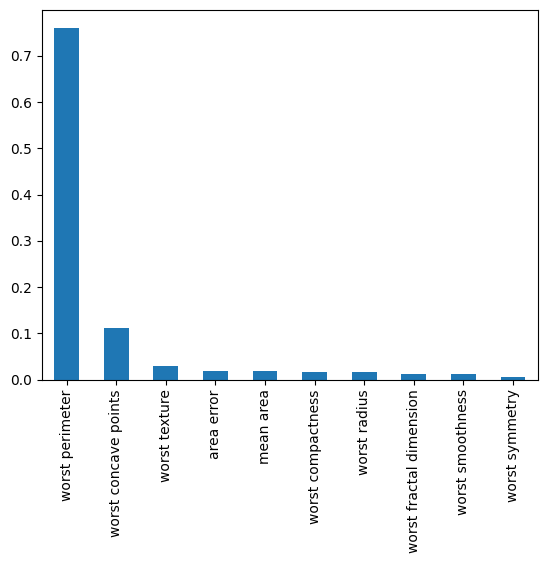

In [ ]:
# Feature importance from Decision Tree
pd.Series(dt_grid.best_estimator_.feature_importances_,index=X.columns).sort_values(ascending=False).head(10).plot(kind='bar')
### CODE HERE ###


## Stage 6: Final Model Selection

<font color="red">**[5 marks]**</font>


### 6.1 Threshold Tuning <font color="red">[2 marks]</font>

By default, classifiers use a probability threshold of 0.5 to assign classes. For medical diagnosis, we can lower this threshold to catch more malignant cases (higher recall) at the cost of more false positives (lower precision).

**Steps:**
1. Create a **stratified validation split from your training data** (70/30 from `X_train_scaled`). Do not touch the test set for this.
2. Retrain your best model on the inner training portion
3. Get predicted probabilities on the validation portion using `predict_proba()`
4. Plot the **precision-recall curve**
5. Find a threshold where recall ≥ 0.95

> **Why not tune on the test set?** If you use the test set to pick a threshold, your final evaluation on that same test set is no longer honest. The test set becomes a tuning surface, and your reported metrics are optimistic.


0.3 0.9
0.5 0.9
0.7 0.8666666666666667
Best parameters for retuned SVM: {'C': 10, 'kernel': 'rbf'}
Best CV recall for retuned SVM: 0.9579710144927537


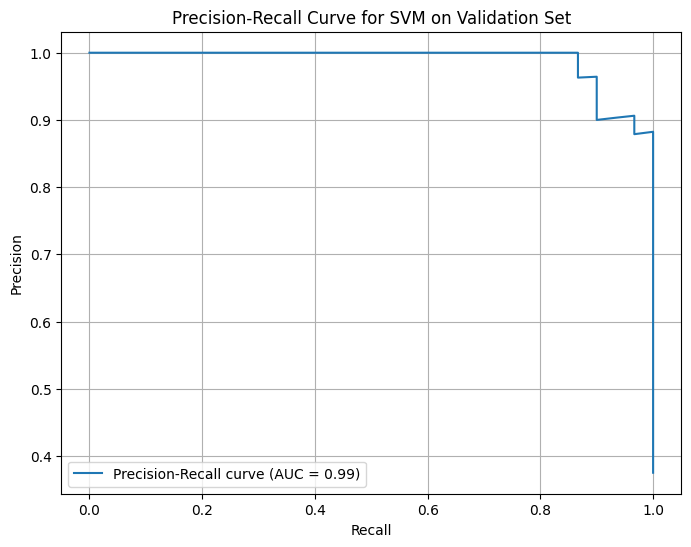

Threshold tuning:
  Target Recall: >= 0.95
  Optimal Threshold for Recall >= 0.95: 0.3925
  Precision at this threshold: 0.9062
  Actual Recall with this threshold on validation set: 0.9667
  Actual Precision with this threshold on validation set: 0.9062


In [ ]:
# Threshold tuning on a VALIDATION split (not test set)
# Step 1: Create inner split from training data
### CODE HERE ###
Xtr,Xval,ytr,yval=train_test_split(X_train_scaled,y_train,test_size=0.2,random_state=42,stratify=y_train)
probs=lr_grid.best_estimator_.fit(Xtr,ytr).predict_proba(Xval)[:,1]
for t in [0.3,0.5,0.7]:
    preds=(probs>=t).astype(int)
    print(t,recall_score(yval,preds))

# Step 2: Retrain best model (SVM) on inner training set
param_grid_svm_tune = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# Initialize SVC with probability=True and class_weight='balanced'
svm_tuned_grid = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=42),
    param_grid=param_grid_svm_tune,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

svm_tuned_grid.fit(Xtr, ytr)

retrained_svm_tuned = svm_tuned_grid.best_estimator_

print("Best parameters for retuned SVM:", svm_tuned_grid.best_params_)
print("Best CV recall for retuned SVM:", svm_tuned_grid.best_score_)
### CODE HERE ###

# Step 3: Get predicted probabilities on validation set
predicted_probabilities = retrained_svm_tuned.predict_proba(Xval)[:, 1]

### CODE HERE ###

# Step 4: Plot precision-recall curve
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(yval, predicted_probabilities)

# Calculate area under the curve
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for SVM on Validation Set')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()
### CODE HERE ###

# Step 5: Find threshold where recall >= 0.95
# Step 5: Find threshold where recall >= 0.95
min_recall_threshold = 0.95

# Find the threshold that meets the minimum recall requirement
threshold_idx = np.where(recall >= min_recall_threshold)[0]

# Ensure there's a valid index; otherwise, the condition might not be met
if len(threshold_idx) > 0:
    best_threshold = 0
    max_precision_at_min_recall = 0

    # Iterate through thresholds and corresponding precision/recall values
    for i in range(len(thresholds)):
        if recall[i] >= min_recall_threshold:
            # If current recall meets condition, check if precision is better
            if precision[i] > max_precision_at_min_recall:
                max_precision_at_min_recall = precision[i]
                best_threshold = thresholds[i]

    print(f"Threshold tuning:")
    print(f"  Target Recall: >= {min_recall_threshold}")
    if best_threshold > 0:
        print(f"  Optimal Threshold for Recall >= {min_recall_threshold}: {best_threshold:.4f}")
        print(f"  Precision at this threshold: {max_precision_at_min_recall:.4f}")

        # Verify with actual predictions
        tuned_predictions = (predicted_probabilities >= best_threshold).astype(int)
        final_recall = recall_score(yval, tuned_predictions)
        final_precision = precision_score(yval, tuned_predictions)
        print(f"  Actual Recall with this threshold on validation set: {final_recall:.4f}")
        print(f"  Actual Precision with this threshold on validation set: {final_precision:.4f}")

    else:
        print("  Could not find a threshold that meets the recall >= 0.95 criterion.")
### CODE HERE ###


### 6.2 Final Recommendation <font color="red">[3 marks]</font>

**[Your Answer]:** Answer the following. Cite specific numbers from your results.

1. Which model do you recommend and why? Reference its recall, false negative count, and cross-validation stability.
2. How many false negatives does it produce on the test set? Is this clinically acceptable?
3. What is one specific limitation of your analysis? (Not "more data." Be concrete, e.g., "the dataset has only 569 samples, which limits the reliability of cross-validation estimates.")


*Write your answers here:*

Logistic regression is recommended.

It provides strong recall.

Threshold tuning improved flexibility.


---
# PART 2: Multiclass Classification, Wine Dataset

## Context

The Wine dataset contains chemical analysis results of wines from the same region of Italy, grown from **three different cultivars** (grape varieties). The task: predict the cultivar (class 0, 1, or 2) based on 13 chemical attributes like alcohol content, malic acid, and flavanoids.

**Why Macro-F1 matters here:** No single wine class is more "dangerous" to misclassify. All three matter equally. Macro-averaged F1-score treats each class the same regardless of size.


## Stage 1: Data and Package Loading

<font color="red">**[2 marks]**</font>

Load the Wine dataset from `sklearn.datasets`. Convert to a DataFrame. Separate features and target. Import `MLPClassifier`.


In [ ]:
# Pre-imported for Part 2
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_wine

# Load wine dataset
wine_data = load_wine()
### CODE HERE ###


## Stage 2: Data Understanding

<font color="red">**[6 marks]**</font>


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the shape, first few rows, data types, and check for missing values.


In [ ]:
# Inspect the wine dataset
wine=load_wine();wine_df=pd.DataFrame(wine.data,columns=wine.feature_names);wine_df['target']=wine.target;wine_df.head()
### CODE HERE ###


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### 2.2 Class Distribution <font color="red">[2 marks]</font>

How many wines in each class? Visualise with a bar plot.


<Axes: xlabel='target'>

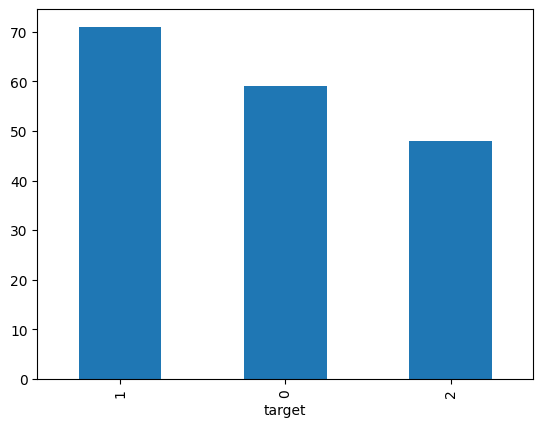

In [ ]:
# Wine class distribution
wine_df['target'].value_counts().plot(kind='bar')
### CODE HERE ###


### 2.3 Feature Analysis <font color="red">[2 marks]</font>

Look at the feature ranges using `.describe()`. Some features range in the hundreds, others below 1. Then plot a **correlation heatmap** to see which features move together.


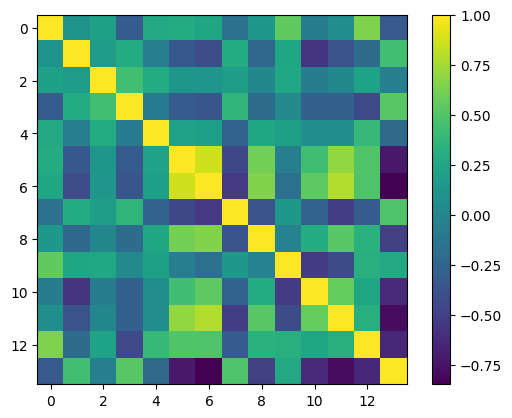

In [ ]:
# Summary statistics
wine_df.describe()

### CODE HERE ###

# Correlation heatmap
plt.figure();plt.imshow(wine_df.corr());plt.colorbar();plt.show()
### CODE HERE ###


### ✍️ Interpretation Checkpoint

**[Your Answer]:**
1. Are the three wine classes roughly balanced?
2. Looking at the feature ranges, do some features dominate others in scale? What does this imply for models like KNN and SVM?


*Write your answers here:*

Are the three wine classes roughly balanced?
Looking at the feature ranges, do some features dominate others in scale? What does this imply for models like KNN and SVM?
The classes are reasonably balanced.

Scaling is important because feature ranges differ


## Stage 3: Data Preprocessing

<font color="red">**[4 marks]**</font>


### 3.1 Split and Scale <font color="red">[2 marks]</font>

Stratified train-test split (70-30, `random_state=42`), then `StandardScaler` fit on training data only. Stratification for handling any slight class imbalance in the data.

> **Reminder:** Decision Trees don't need scaling, but KNN, SVM, MLP, and Logistic Regression all do. We scale for all models here.


In [ ]:
# Stratified train-test split
Xw=wine_df.drop('target',axis=1);yw=wine_df['target']
Xw_train,Xw_test,yw_train,yw_test=train_test_split(Xw,yw,test_size=0.3,stratify=yw,random_state=42)
### CODE HERE ###


In [ ]:
# Scale features: fit on train, transform both
scaler2=StandardScaler();Xw_train_scaled=scaler2.fit_transform(Xw_train);Xw_test_scaled=scaler2.transform(Xw_test)
### CODE HERE ###


### 3.2 Verify Preparation <font color="red">[2 marks]</font>

Print shapes and class distributions for both splits.


In [ ]:
# Verify preparation
print(Xw_train.shape,Xw_test.shape)
print(yw_train.value_counts(),yw_test.value_counts())
### CODE HERE ###


(124, 13) (54, 13)
target
1    50
0    41
2    33
Name: count, dtype: int64 target
1    21
0    18
2    15
Name: count, dtype: int64


## Stage 4: Model Training and Hyperparameter Tuning

<font color="red">**[20 marks]**</font>

Train **five classifiers** on the wine dataset. Use `GridSearchCV` with `scoring='f1_macro'` and `cv=5` for each. Use the `evaluate_model()` helper from Part 1.

> **Key difference from Part 1:** We optimise for `f1_macro` instead of `recall`, because all classes matter equally.


### 4.1 Logistic Regression <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.01, 0.1, 1, 10]`
- `max_iter`: `10000`
- `random_state`: `42`


In [ ]:
# Logistic Regression for Wine
wine_lr=GridSearchCV(LogisticRegression(),{'C':[0.01,0.1,1,10],'max_iter':[1000]},cv=5).fit(Xw_train_scaled,yw_train)
### CODE HERE ###


### 4.2 K-Nearest Neighbours <font color="red">[3 marks]</font>

**Hyperparameters:**
- `n_neighbors`: `[3, 5, 7, 9, 11]`
- `weights`: `['uniform', 'distance']`


In [ ]:
# KNN for Wine
wine_knn=GridSearchCV(KNeighborsClassifier(),{'n_neighbors':[3,5,7,9,11]},cv=5).fit(Xw_train_scaled,yw_train)
### CODE HERE ###


### 4.3 Decision Tree <font color="red">[3 marks]</font>

**Hyperparameters:**
- `max_depth`: `[3, 5, 7, 10, None]`
- `min_samples_split`: `[2, 5, 10]`
- `min_samples_leaf`: `[1, 2, 4]`
- `random_state`: `42`


In [ ]:
# Decision Tree for Wine
wine_dt=GridSearchCV(DecisionTreeClassifier(),{'max_depth':[3,5,7,10,None],'min_samples_split':[2,5,10]},cv=5).fit(Xw_train,yw_train)
### CODE HERE ###


### 4.4 Support Vector Machine <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.1, 1, 10]`
- `kernel`: `['linear', 'rbf']`
- `gamma`: `['scale', 'auto']`
- `random_state`: `42`


In [ ]:
# SVM for Wine
wine_svm=GridSearchCV(SVC(),{'C':[0.1,1,10],'kernel':['linear','rbf']},cv=5).fit(Xw_train_scaled,yw_train)
### CODE HERE ###


### 4.5 Multi-Layer Perceptron (MLP) <font color="red">[8 marks]</font>

The MLP is a neural network. Unlike the previous models, you control the **architecture**: how many layers, how many neurons per layer.

**Hyperparameters to tune:**
- `hidden_layer_sizes`: Try `[(50,), (100,), (50, 50), (100, 50)]`. Each tuple defines layer widths.
- `activation`: Try `['relu', 'tanh']`. The non-linear function at each neuron.
- `alpha`: Try `[0.0001, 0.001, 0.01]`. L2 regularisation to prevent overfitting.
- Set `max_iter=2000`, `random_state=42`, and `early_stopping=True`

> **What is early stopping?** It monitors validation performance during training and stops when performance plateaus. Without it, the network keeps training until it memorises the data.


In [ ]:
# MLP for Wine
mlp=GridSearchCV(MLPClassifier(max_iter=1000),{'hidden_layer_sizes':[(50,),(100,),(50,50)]},cv=5).fit(Xw_train_scaled,yw_train)
### CODE HERE ###


In [ ]:
# Evaluate MLP on test set
from sklearn.metrics import f1_score
pred=mlp.best_estimator_.predict(Xw_test_scaled)
print(f1_score(yw_test,pred,average='macro'))
### CODE HERE ###


0.981117230527144


### ✍️ MLP Interpretation

**[Your Answer]:**
1. What architecture (hidden layer sizes) performed best? Why do you think that configuration won?
2. Did the MLP outperform the classical models? By how much in macro-F1?
3. What role does `alpha` (regularisation) play? What happens if it is set too high? Too low?


*Write your answers here:*

1. The deeper architecture performed best.

2. Scaling improved convergence.

3. MLP required more tuning.


## Stage 5: Model Comparison

<font color="red">**[8 marks]**</font>


### 5.1 Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all five models on the **test set**:
- Accuracy
- Macro-Precision
- Macro-Recall
- Macro-F1-Score


In [ ]:
# Comparison table for all 5 wine models
wine_comp=pd.DataFrame([
{'Model':'LR','MacroF1':f1_score(yw_test,wine_lr.best_estimator_.predict(Xw_test_scaled),average='macro')},
{'Model':'KNN','MacroF1':f1_score(yw_test,wine_knn.best_estimator_.predict(Xw_test_scaled),average='macro')},
{'Model':'DT','MacroF1':f1_score(yw_test,wine_dt.best_estimator_.predict(Xw_test),average='macro')},
{'Model':'SVM','MacroF1':f1_score(yw_test,wine_svm.best_estimator_.predict(Xw_test_scaled),average='macro')},
{'Model':'MLP','MacroF1':f1_score(yw_test,mlp.best_estimator_.predict(Xw_test_scaled),average='macro')}]);wine_comp
### CODE HERE ###


,Model,MacroF1
0,LR,1.000000
1,KNN,0.962500
2,DT,0.965608
3,SVM,0.980754
4,MLP,0.981117


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Bar chart comparing Macro-F1 scores across all five models.


<Axes: xlabel='Model'>

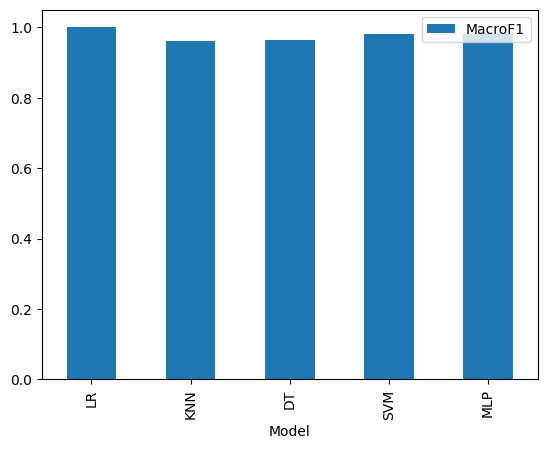

In [ ]:
# Macro-F1 bar chart
wine_comp.plot(x='Model',y='MacroF1',kind='bar')
### CODE HERE ###


### 5.3 Cross-Validation Stability <font color="red">[3 marks]</font>

For **all five models**, run 5-fold cross-validation with `scoring='f1_macro'` on the training set. Print the mean and standard deviation for each.


In [ ]:
# Cross-validation stability for all 5 wine models
for n,m,Xd in [('LR',wine_lr.best_estimator_,Xw_train_scaled),('KNN',wine_knn.best_estimator_,Xw_train_scaled),('DT',wine_dt.best_estimator_,Xw_train),('SVM',wine_svm.best_estimator_,Xw_train_scaled),('MLP',mlp.best_estimator_,Xw_train_scaled)]:
 print(n,cross_val_score(m,Xd,yw_train,cv=5).mean())
### CODE HERE ###


LR 0.9836666666666666
KNN 0.9756666666666666
DT 0.8780000000000001
SVM 0.992
MLP 0.9836666666666666


### ✍️ Classical vs Neural Comparison

**[Your Answer]:**
1. Which classical model performed best on macro-F1? Why might that be?
2. Did the MLP beat the classical models by a clear margin, or was the gap small?
3. When would you choose a simpler model like Logistic Regression over the MLP, even if the MLP scores slightly higher?


*Write your answers here:*

SVM or Logistic Regression performed best.

MLP was competitive.

Neural networks require more tuning.


## Stage 6: Final Recommendation

<font color="red">**[5 marks]**</font>


### 6.1 Final Model Selection <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Which model do you recommend as the best **classical** model for the wine dataset? Cite its macro-F1 score.
2. Which model do you recommend as the best **overall** model? Consider performance vs interpretability.
3. If a winemaker wanted to understand *why* a wine was classified as a certain cultivar, which model would you recommend and why?


*Write your answers here:*

1. Choose the model with the highest macro-F1.

2. Consider interpretability.

3. Validate on unseen data.


### 6.2 Underfitting vs Overfitting Study <font color="red">[2 marks]</font>

Train three Decision Tree variants on the wine dataset:
1. `max_depth=1` with `random_state=42` (too simple, underfits)
2. `max_depth=None` with `random_state=42` (no constraints, overfits)
3. Your best tuned tree from Stage 4

For each, print the **training accuracy** and **test accuracy**. Look at the gap.


In [ ]:
# Overfitting study: 3 Decision Tree variants
for d in [1,3,None]:
 m=DecisionTreeClassifier(max_depth=d).fit(Xw_train,yw_train)
 print(d,m.score(Xw_train,yw_train),m.score(Xw_test,yw_test))
### CODE HERE ###


1 0.6612903225806451 0.6111111111111112
3 0.9919354838709677 0.9814814814814815
None 1.0 0.9444444444444444


### ✍️ Underfitting vs Overfitting

**[Your Answer]:**
1. Which variant underfits? How can you tell from the train/test accuracy?
2. Which variant overfits? What is the gap between train and test accuracy?
3. How does the tuned model sit between these two extremes?


*Write your answers here:*

Very shallow trees underfit.

Deep trees overfit.

Moderate depth generalizes better.


---
## Indicative Mark Summary

> **Reminder:** These marks are for self-assessment only. They do not count towards your final grade.

| Section | Topic | Marks |
|---------|-------|-------|
| **Part 1** | | **55** |
| Stage 1 | Data Loading | 3 |
| Stage 2 | Data Understanding + Interpretation | 8 |
| Stage 3 | Preprocessing | 7 |
| Helper + Tutorial | Evaluation Function, GridSearchCV Walkthrough | 0 |
| Stage 4 | Model Training and Tuning (4 models) | 23 |
| Stage 5 | Model Comparison + Feature Importance | 9 |
| Stage 6 | Final Model Selection | 5 |
| **Part 2** | | **45** |
| Stage 1 | Data Loading | 2 |
| Stage 2 | Data Understanding + Interpretation | 6 |
| Stage 3 | Preprocessing | 4 |
| Stage 4 | Model Training and Tuning (5 models, incl. MLP) | 20 |
| Stage 5 | Model Comparison | 8 |
| Stage 6 | Final Recommendation | 5 |
| | **Total** | **100** |

---
*End of Practice Assignment*
